<a href="https://colab.research.google.com/github/Fedorov-Kirill/-Pavlova/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F%2C_%D0%B3%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B9_%D1%81%D0%BF%D1%83%D1%81%D0%BA_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **План**

- Реализация алгоритма стохастического градиентного спуска:
    - загрузка данных
    - создание и обучение алгоритма
- Сравнение написанного алгоритма с реализованным в библиотеке Sklearn.

- Рекомендованная литература

ноутбук в колаб: https://drive.google.com/file/d/1aqRvKK0WRq8hn89bm1O__khM5cg1wuW7/view?usp=sharing

# Реализуем алгоритм стохастического градиентного спуска

In [ ]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

## Загрузка и подготовка данных

### **Постановка задачи:**
Предсказать вероятность одобрения заявки на поступление в ВУЗ (вероятность от 0 до 1) по набору признаков: оценки за экзамены, наличие research и тд

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/tixonsit/mmdad_materials/master/datasets_14872_228180_Admission_Predict_Ver1.1.csv')
del df['Serial No.']

In [ ]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
# мало :(
len(df)

500

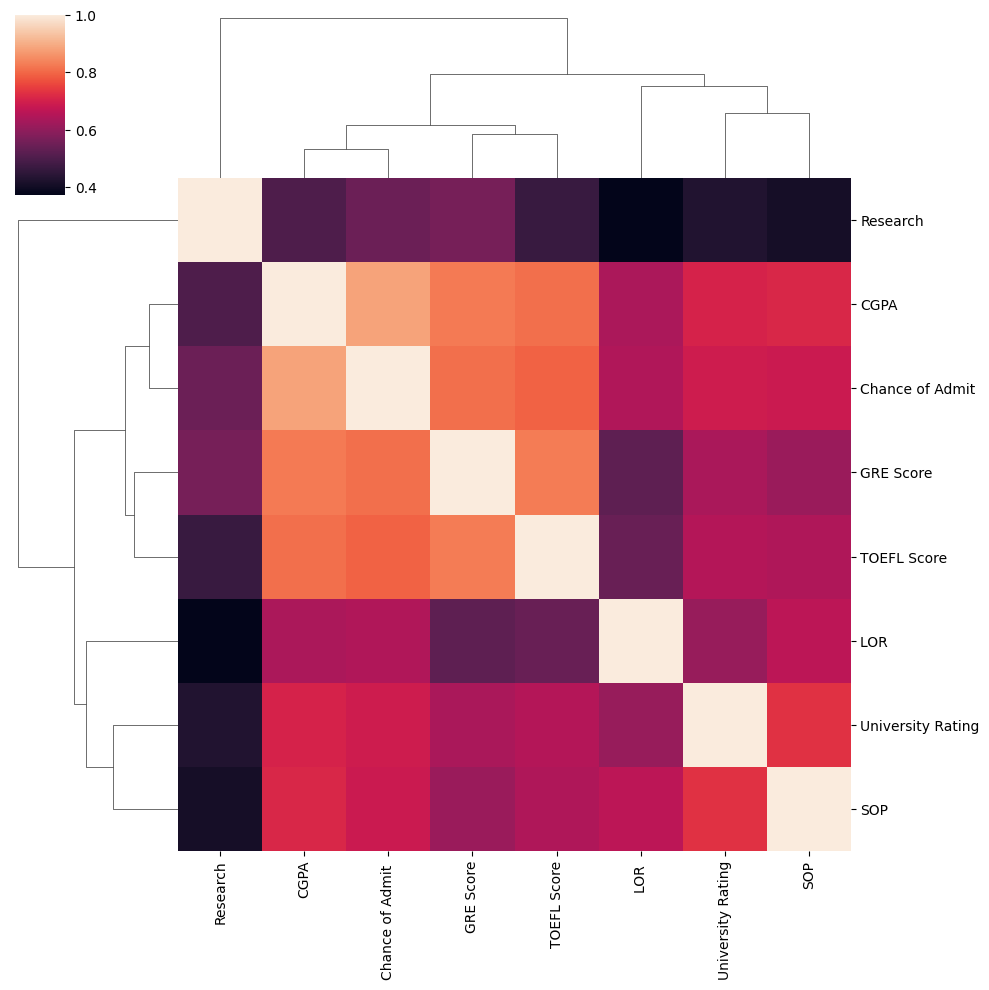

In [ ]:
import seaborn as sns

sns.clustermap(df.corr())

In [ ]:
# перемешка
df = df.sample(frac=1).reset_index(drop=True)
# train test split
df_train = df[:400]
df_test = df[400:]
# среднее и стандартное отклонение
mean = df.mean(axis=0)
std = df.std(axis=0)
# 0 мат ожидание и 1 дисперсию
df_train = (df_train - mean)/std

X_train = df_train.drop(columns=['Chance of Admit ']).values
y_train = df_train['Chance of Admit '].values
df_test = (df_test - mean)/std
X_test = df_test.drop(columns=['Chance of Admit ']).values
y_test = df_test['Chance of Admit '].values

In [ ]:
X_train[:5]

array([[ 1.99448465,  1.11939299,  1.64930524,  0.63168286,  1.0978448 ,
         1.95690303,  0.88551841],
       [ 1.37474954,  1.44823934,  1.64930524,  1.64076091,  1.63812275,
         1.16326903,  0.88551841],
       [-0.48445579, -0.85368513, -0.09969289,  1.13622188,  0.55756685,
         0.10509037,  0.88551841],
       [ 1.19768236,  2.10593205,  1.64930524,  1.13622188,  1.63812275,
         1.6262222 ,  0.88551841],
       [-0.75005655, -1.01810831, -0.97419196, -0.37739519,  0.55756685,
        -1.11842871, -1.12702343]])

In [ ]:
y_train[:5]

array([ 1.68810626,  1.5464034 , -0.29573389,  1.47555196, -0.29573389])

## Создание алгоритма

In [ ]:
print('размерность пространства признаков:', X_train.shape[1])
# инициализация весов под размерность пространства признаков
w = np.ones(X_train.shape[1])
# выбираем случайный индекс, по которому найдем частную производную
ind = np.random.randint(X_train.shape[1])
print('Случайный индекс', ind)
# переможим выбранный столбец на нужный вес (получаем кол-во элементов train)
len(np.dot(X_train[:,ind], w[ind]))

размерность пространства признаков: 7
Случайный индекс 0


400

$$MSE = \frac{1}{n}\sum_{i = 1}^{n}(y_i - \hat{y_i})^2$$

Реализуем ошибку по формуле:

In [ ]:
mse = lambda y, y_pred:((y-y_pred)**2).sum()/len(y_pred)

In [ ]:
# очистка экрана
from google.colab import output
# коэффициент детерминации
from sklearn.metrics import r2_score

Стохастический градиентный спуск (англ. stochastic gradient descent, SGD) − оптимизационный алгоритм, отличающийся от обычного градиентного спуска тем, что градиент оптимизируемой функции считается на каждом шаге не как сумма градиентов от каждого элемента выборки, а как градиент от одного, случайно выбранного элемента.

![dssmall](https://github.com/m9psy/neural_network_habr_guide/blob/master/Part%203/images/stochastic.gif?raw=true)

$$w_{t+1} = w_{t} - \frac{2\alpha}{n}X_i(<X_i, w_{t}> - y_i) $$

Реализуем шаг по формуле

In [ ]:
gradient_step_stah = lambda X, y, w, alpha, ind: w - (alpha* 2.0 / X.shape[0]) * X[ind] * (np.dot(X[ind], w) - y[ind])

In [ ]:
# выбрали случайный индекс
ind = np.random.randint(X_train.shape[1])
# сделали один шаг (w = [1, 1, ...])
gradient_step_stah(X_train, y_train, np.ones(X_train.shape[1]), 1e-4, ind)

array([0.99999831, 0.9999977 , 0.9999978 , 0.99999915, 1.00000126,
       0.99999748, 0.99999746])

In [ ]:
X_train.shape[1]

7

## Обучение алгоритма

In [ ]:
# стохастический градиентный спуск
def sgd(X, y, w, alpha = 1e-4, max_it = 10e6):
    # номер итерации
    iter_num = 0
    # ошибки на трейне
    errors = []
    # ошибки на тесте
    errors_test = []
    # r2 на тесте
    r2 = []
    while (iter_num < max_it):
        # выбираем случайный элемент
        ind = np.random.randint(X.shape[0])
        # обновляем веса град спуском
        w = gradient_step_stah(X, y, w, alpha, ind)
        # отображаем каждый %
        if iter_num%(int(max_it/100))==0:
            # очищаем экран

            print('Выполнено:', int(iter_num/max_it * 100), '%')
            # mse train
            error = mse(y_train,np.dot(X_train, w))
            errors.append(error)
            print('Mse train:', error)
            # mse test
            error = mse(y_test,np.dot(X_test, w))
            errors_test.append(error)
            print('Mse test:', error)
            # r2 test
            R = r2_score(y_test,np.dot(X_test, w))
            r2.append(R)
            print('R2:', R)
        iter_num += 1

    return w, errors, errors_test, r2

w, mse_train, mse_test, r2 = sgd(X_train, y_train, np.ones(X_train.shape[1]))

Выполнено: 0 %
Mse train: 23.28712916024092
Mse test: 24.786661113251967
R2: -25.35192466530965
Выполнено: 1 %
Mse train: 14.716947845137028
Mse test: 15.716867095381238
R2: -15.70937831359377
Выполнено: 2 %
Mse train: 9.334902086865455
Mse test: 10.004968119490638
R2: -9.636776165979203
Выполнено: 3 %
Mse train: 5.934434253272445
Mse test: 6.382897222219254
R2: -5.78597355157321
Выполнено: 4 %
Mse train: 3.8268942498597225
Mse test: 4.128047344662205
R2: -3.3887311866788963
Выполнено: 5 %
Mse train: 2.4994136964203624
Mse test: 2.699916907329857
R2: -1.8704151244684408
Выполнено: 6 %
Mse train: 1.668669733590287
Mse test: 1.8000762777728163
R2: -0.9137500709330839
Выполнено: 7 %
Mse train: 1.1458842556344087
Mse test: 1.22912550231301
R2: -0.3067440787273439
Выполнено: 8 %
Mse train: 0.8158611833131308
Mse test: 0.8649905115787259
R2: 0.08038582957252194
Выполнено: 9 %
Mse train: 0.6084122605409902
Mse test: 0.63321614859258
R2: 0.32679661176115726
Выполнено: 10 %
Mse train: 0.4769863

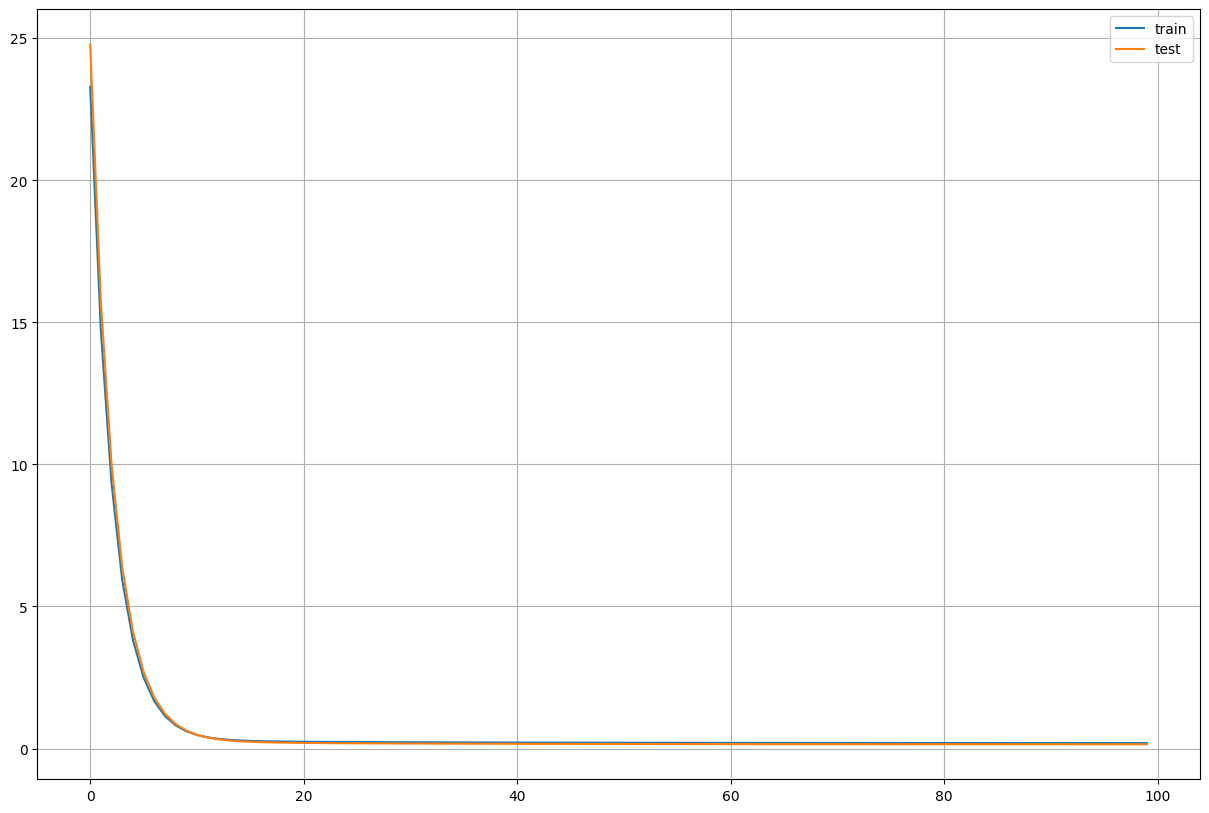

In [ ]:
from matplotlib.pyplot import figure

plt.figure(figsize=(15,10))
plt.grid()

plt.plot(mse_train, label = 'train')
plt.plot(mse_test, label = 'test')
plt.legend()

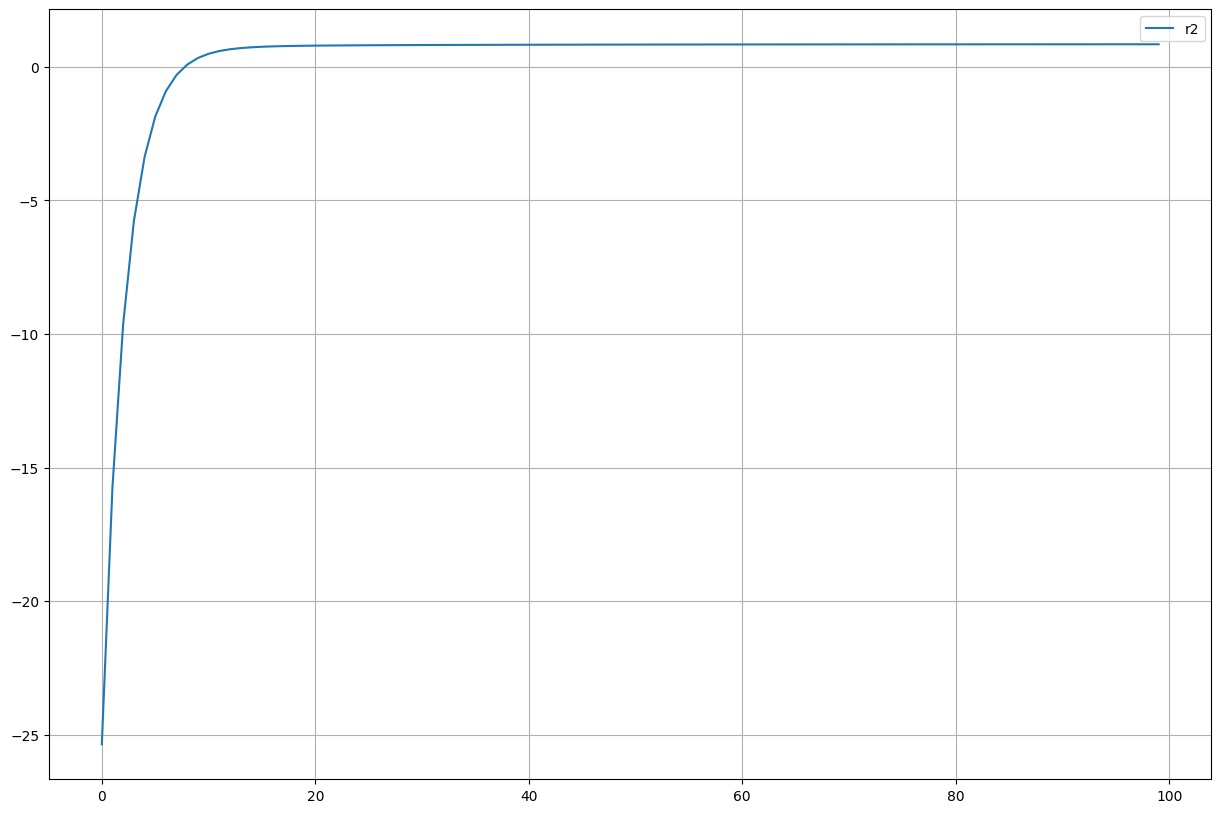

In [ ]:
from matplotlib.pyplot import figure

plt.figure(figsize=(15,10))
plt.grid()

plt.plot(r2, label = 'r2')
plt.legend()

In [ ]:
print('веса', w)
print('R^2 = ', r2_score(y_test, np.dot(X_test,w)))

веса [0.19882844 0.16639798 0.07413661 0.03272255 0.13046175 0.3512163
 0.10003991]
R^2 =  0.8410584723862315


In [ ]:
# массив результатов
r2_shuffles = []
# проверим, зависит ли изначальная перемешка от результата
for i in range(2):
    print(f'Итерация {i+1}')
    # перемешка
    df = df.sample(frac=1).reset_index(drop=True)
    # train test split
    df_train = df[:400]
    df_test = df[400:]
    # среднее и стандартное отклонение
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    # 0 мат ожидание и 1 дисперсию
    df_train = (df_train - mean)/std
    X_train = df_train.drop(columns=['Chance of Admit ']).values
    y_train = df_train['Chance of Admit '].values
    df_test = (df_test - mean)/std
    X_test = df_test.drop(columns=['Chance of Admit ']).values
    y_test = df_test['Chance of Admit '].values

    w, mse_train, mse_test, r2 = sgd(X_train, y_train, np.ones(X_train.shape[1]))
    print(f'Итерация {i+1} | R^2 = ', r2_score(y_test, np.dot(X_test,w)))
    r2_shuffles.append(r2_score(y_test, np.dot(X_test,w)))

Итерация 1
Выполнено: 0 %
Mse train: 22.4857475210582
Mse test: 27.99218270577464
R2: -23.273285798465142
Выполнено: 1 %
Mse train: 14.51448568079964
Mse test: 17.9781585997558
R2: -14.589673245880238
Выполнено: 2 %
Mse train: 9.368778914938456
Mse test: 11.52285221784353
R2: -8.991985549576091
Выполнено: 3 %
Mse train: 6.0841268461841835
Mse test: 7.409579160948238
R2: -5.425180719578006
Выполнено: 4 %
Mse train: 3.9891293032671227
Mse test: 4.792142719058074
R2: -3.1554833729609104
Выполнено: 5 %
Mse train: 2.6424632466573503
Mse test: 3.1146271059592117
R2: -1.700833825402189
Выполнено: 6 %
Mse train: 1.7893563178047824
Mse test: 2.0560054083719206
R2: -0.7828551422789305
Выполнено: 7 %
Mse train: 1.2363492378891996
Mse test: 1.3732053302987408
R2: -0.19076835817597027
Выполнено: 8 %
Mse train: 0.885873665381892
Mse test: 0.943376728138404
R2: 0.18195543454349772
Выполнено: 9 %
Mse train: 0.6592761548614573
Mse test: 0.6678433655748554
R2: 0.4208828567747557
Выполнено: 10 %
Mse trai

{'whiskers': [<matplotlib.lines.Line2D at 0x78184f2af0a0>,
 'caps': [<matplotlib.lines.Line2D at 0x78184f2af5e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78184f2aee00>],
 'medians': [<matplotlib.lines.Line2D at 0x78184f2afb20>],
 'fliers': [<matplotlib.lines.Line2D at 0x78184f2afdc0>],
 'means': []}

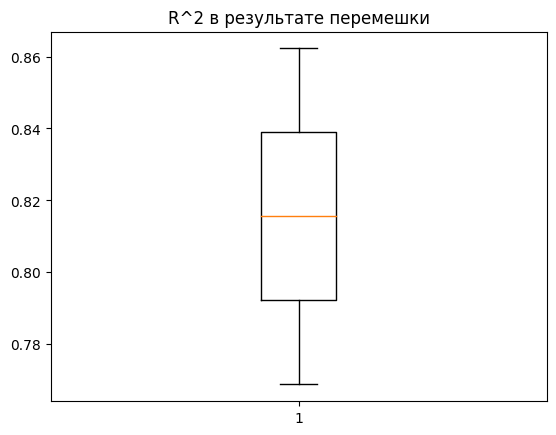

In [ ]:
fig1, ax1 = plt.subplots()
ax1.set_title('R^2 в результате перемешки')
ax1.boxplot(r2_shuffles)

Вывод: сильно зависит от перемешки -> данные нерепрезентативны -> накапливаем еще или аугментируем

# Сравнение с Sklearn

## Обучение с помощью sklearn

In [ ]:
from sklearn.linear_model import SGDRegressor
# инициализируем и обучаем
reg = SGDRegressor()
reg.fit(X_train, y_train)

SGDRegressor()

In [ ]:
print('Mse sgd (sklearn): ', r2_score(y_test, reg.predict(X_test)))

Mse sgd (sklearn):  0.7689920281885582


Настраиваем тонко

In [ ]:
from sklearn.model_selection import GridSearchCV

grid = {'penalty': ['l1', 'l2'],
        'alpha': [1e-4, 1e-5, 1e-6, 1e-7]}

reg = SGDRegressor()
gs = GridSearchCV(reg, grid, cv=5)

# Обучаем его
gs.fit(X_train, y_train)
gs.best_params_, gs.best_score_

({'alpha': 1e-07, 'penalty': 'l1'}, 0.8165120250909979)

In [ ]:
from sklearn.linear_model import SGDRegressor
# инициализируем и обучаем
reg = SGDRegressor(alpha = 1e-05, penalty = 'l2')
reg.fit(X_train, y_train)

SGDRegressor(alpha=1e-05)

In [ ]:
print('Mse sgd (sklearn): ', r2_score(y_test, reg.predict(X_test)))

Mse sgd (sklearn):  0.8248246395620243


In [ ]:
fin_score = []

for i in range(30):
    print(f'Итерация {i+1}')
    # перемешка
    df = df.sample(frac=1).reset_index(drop=True)
    # train test split
    df_train = df[:400]
    df_test = df[400:]
    # среднее и стандартное отклонение
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    # 0 мат ожидание и 1 дисперсию
    df_train = (df_train - mean)/std
    X_train = df_train.drop(columns=['Chance of Admit ']).values
    y_train = df_train['Chance of Admit '].values
    df_test = (df_test - mean)/std
    X_test = df_test.drop(columns=['Chance of Admit ']).values
    y_test = df_test['Chance of Admit '].values

    # обучение
    grid = {'penalty': ['l1', 'l2'],
            'alpha': [1e-4, 1e-5, 1e-6, 1e-7]}

    reg = SGDRegressor()
    gs = GridSearchCV(reg, grid, cv=5, scoring = 'r2')

    # Обучаем его
    gs.fit(X_train, y_train)
    print(gs.best_score_)
    fin_score.append(gs.best_score_)

Итерация 1
0.8135007564462693
Итерация 2
0.8040631838899325
Итерация 3
0.8037169413007306
Итерация 4
0.8114948987308452
Итерация 5
0.824493222801693
Итерация 6
0.7965409716868811
Итерация 7
0.8157026115998993
Итерация 8
0.8047026371196738
Итерация 9
0.8056952318426365
Итерация 10
0.8266467045159047
Итерация 11
0.7964185446077321
Итерация 12
0.8199728344765134
Итерация 13
0.7968928874193
Итерация 14
0.8038160424820362
Итерация 15
0.8251381383844884
Итерация 16
0.8043074214824865
Итерация 17
0.7971081503468858
Итерация 18
0.8259930406606758
Итерация 19
0.8040416672741285
Итерация 20
0.7987725465622697
Итерация 21
0.8175140002096699
Итерация 22
0.7977815276048441
Итерация 23
0.8118165115172438
Итерация 24
0.7987435015653791
Итерация 25
0.8222908482285394
Итерация 26
0.8089375917202336
Итерация 27
0.8041522233793674
Итерация 28
0.8000822340978567
Итерация 29
0.8153226373434022
Итерация 30
0.8063070937648833


{'whiskers': [<matplotlib.lines.Line2D at 0x78184eadae90>,
 'caps': [<matplotlib.lines.Line2D at 0x78184eadb3d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78184eadabf0>],
 'medians': [<matplotlib.lines.Line2D at 0x78184eadb910>],
 'fliers': [<matplotlib.lines.Line2D at 0x78184eadbbb0>],
 'means': []}

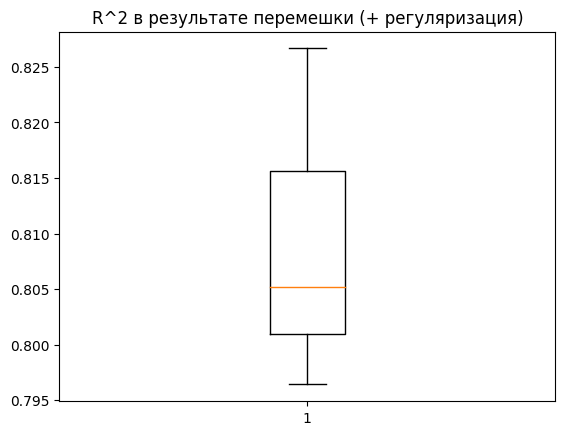

In [ ]:
fig1, ax1 = plt.subplots()
ax1.set_title('R^2 в результате перемешки (+ регуляризация)')
ax1.boxplot(fin_score)

# Вывод

- Реализован стохастический градиентный спуск (СГС) для задачи линейной регрессии

- Приведено сравнение написанного СГС и реализованного в библиотеке sklearn


# Рекомендованная литература


- [Линейная регрессия в подробностях](https://habr.com/ru/company/ods/blog/322076/)


- [Функция ошибок в задачах регрессии](https://alexanderdyakonov.files.wordpress.com/2018/10/book_08_metrics_12_blog1.pdf)

- Градиентный спуск:
    - [Часть 1](https://habr.com/ru/post/307312/)
    - [Часть 2](https://habr.com/ru/post/308604/)
